In [ ]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json
import re
import math
sys.path.append('..')

from src.utility.config import DEVICE, QUANTIZATION_METHOD, QUANTIZATION_NUM_BITS
from src.layers import QuantizedLayers, replace_layers_with_quantizable
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.utility.quantizer import Quantization



# Set style
sns.set_theme(style="whitegrid")



In [13]:
def prepare_quantized_architecture(model):
    print("--- Starte Anpassung der Architektur für Quantisierung ---")
    count = 0
    # Wir iterieren durch alle Module
    for name, module in model.named_modules():
        # Statt 'isinstance' prüfen wir einfach, ob die Methode existiert.
        # Das ist viel sicherer gegen Import-Probleme.
        if hasattr(module, 'quantized_storage'):
            module.quantized_storage(
                num_bits=QUANTIZATION_NUM_BITS, 
                method=QUANTIZATION_METHOD
            )
            count += 1
            # Optional: Debug Print für den ersten Layer, um zu sehen, ob es klappt
            if count == 1:
                print(f" -> Erster Layer angepasst: {name}")
                
    print(f"--- Fertig: {count} Layer wurden in den INT8-Modus geschaltet. ---")
    
    if count == 0:
        print("WARNUNG: Es wurden 0 Layer angepasst! Überprüfe src/model.py!")

In [14]:
def load_models(float_path, quant_path):
    # --- 1. Float Modell laden ---
    print(f"Lade Float Modell: {float_path}")
    model_f = CNN(num_classes=898).to(DEVICE)
    
    # FIX: strict=False erlaubt das Ignorieren von 'scale', 'zero_point' etc.
    # die im File stehen, aber für das Float-Modell irrelevant sind.
    model_f.load_state_dict(torch.load(float_path, map_location=DEVICE), strict=False)
    model_f.eval()

    # --- 2. Quantized Modell laden ---
    print(f"Lade Quantized Modell: {quant_path}")
    model_q = CNN(num_classes=898).to(DEVICE)
    
    # Hier müssen wir die Struktur anpassen, damit weight_int existiert
    prepare_quantized_architecture(model_q)
    
    # Hier nutzen wir strict=True (Standard), weil wir sicher sein wollen, 
    # dass alle INT8 Gewichte korrekt geladen werden.
    model_q.load_state_dict(torch.load(quant_path, map_location=DEVICE))
    model_q.eval()
    
    return model_f, model_q

In [15]:
def plot_layer_mse(df):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='layer', y='mse', color='steelblue')
    
    plt.title("Quantization Noise per Layer (MSE)")
    plt.ylabel("Mean Squared Error")
    plt.yscale('log') # Wichtig, um kleine Unterschiede zu sehen!
    plt.xticks(rotation=45) # Damit man die Layernamen lesen kann
    plt.tight_layout()
    plt.show()

In [16]:
def parse_training_logs(log_file_path):
    epochs = []
    losses = []
    
    with open(log_file_path, 'r') as f:
        for line in f:
            # Look for lines like: "Train Epoch: 1 ... Loss: 0.1234"
            if "Train Epoch:" in line and "Loss:" in line:
                # Extract Epoch
                epoch_match = re.search(r'Train Epoch: (\d+)', line)
                loss_match = re.search(r'Loss: ([0-9.]+)', line)
                
                if epoch_match and loss_match:
                    epochs.append(int(epoch_match.group(1)))
                    losses.append(float(loss_match.group(1)))
                    
    return pd.DataFrame({'Epoch': epochs, 'Loss': losses})

In [17]:
def visualize_comparison(model_f, model_q, test_loader, num_images=50):
    # 1. Sicherstellen, dass wir genug Bilder haben
    # Wir iterieren durch den Loader, bis wir genug Bilder gesammelt haben
    data_list, target_list = [], []
    for d, t in test_loader:
        data_list.append(d)
        target_list.append(t)
        if len(torch.cat(data_list)) >= num_images:
            break
            
    # Zusammenfügen und auf richtige Menge kürzen
    data = torch.cat(data_list)[:num_images].to(DEVICE)
    target = torch.cat(target_list)[:num_images].to(DEVICE)

    # 2. Vorhersagen
    with torch.no_grad():
        out_f = model_f(data)
        out_q = model_q(data)
    pred_f = out_f.argmax(dim=1)
    pred_q = out_q.argmax(dim=1)

    # 3. Grid Logik
    cols = 8 # Etwas breiter, damit die Titel passen
    rows = math.ceil(num_images / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
    axes_flat = axes.flatten() 

    # Klassennamen holen (Robust gegen Subset/FullDataset)
    if hasattr(test_loader.dataset, 'classes'):
        class_names = test_loader.dataset.classes
    elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
        class_names = test_loader.dataset.dataset.classes
    else:
        # Fallback falls keine Klassen namen da sind
        class_names = [str(i) for i in range(1000)]

    print(f"Zeige {num_images} Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab")

    for i in range(num_images):
        ax = axes_flat[i]
        
        # Bild vorbereiten (C, H, W) -> (H, W, C)
        img = data[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 # Denormalisieren
        img = np.clip(img, 0, 1) # Sicherheits-Clip für imshow

        ax.imshow(img)
        
        # Indizes
        p_q_idx = pred_q[i].item()
        p_f_idx = pred_f[i].item()
        real_idx = target[i].item()
        
        # Namen
        name_q = class_names[p_q_idx]
        name_real = class_names[real_idx]

        # --- LOGIK: FARBEN & TITEL ---
        is_correct = (p_q_idx == real_idx)
        has_changed = (p_q_idx != p_f_idx) # Quantisierung hat Meinung geändert

        if has_changed:
            color = 'orange'
            # Zeige was Float gesagt hätte in Klammern
            title_text = f"Q: {name_q}\n(F: {class_names[p_f_idx]})"
        else:
            color = 'green' if is_correct else 'red'
            title_text = f"Pred: {name_q}\nReal: {name_real}"

        ax.set_title(title_text, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        
    # Leere Slots ausblenden
    for j in range(num_images, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
# df_learning = parse_training_logs("../results/logs/experiment_2025-12-17_14-12-08.log")

# plt.figure(figsize=(10, 6))
# sns.lineplot(data=df_learning, x="Epoch", y="Loss")
# plt.title("Training Learning Curve")
# plt.xlabel("Epoch")
# plt.ylabel("NLL Loss")
# plt.show()

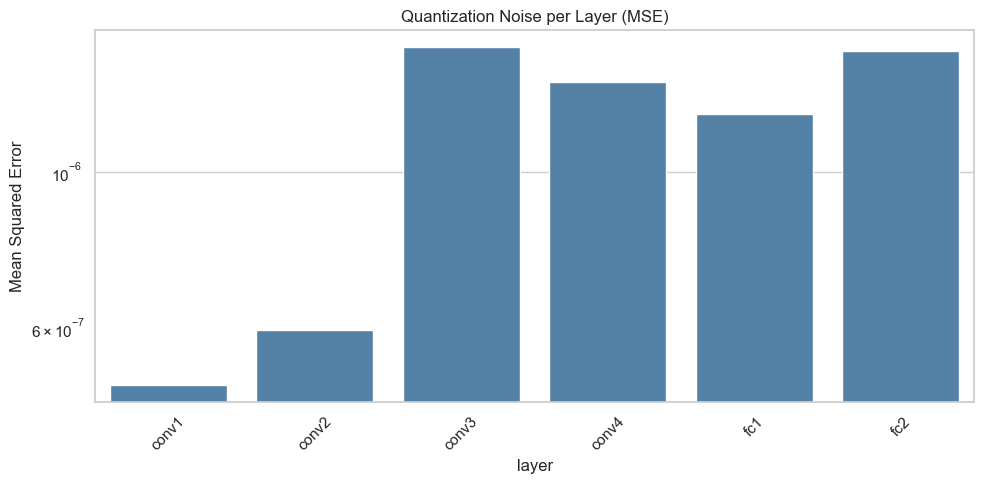

In [19]:
df_loss = pd.read_csv("../results/csv/weight_mse_2026-01-06_19-08-22.csv")

plot = plot_layer_mse(df_loss)


In [20]:
q_model = CNN(num_classes=898)
q_model = replace_layers_with_quantizable(q_model)

for name, module in q_model.named_modules():
    if hasattr(module, 'quantized_storage'):
        module.quantized_storage(num_bits=8, method='symmetry')

q_model.load_state_dict(torch.load("../results/quantized_models/cnn_mnist_quantized2026-01-06_19-28-23.pt"))

q_model.eval()

CNN(
  (conv1): QuantizedConv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): QuantizedConv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): QuantizedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): QuantizedConv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): QuantizedLinear(in_features=1024, out_features=1024, bias=True)
  (fc2): QuantizedLinear(in_features=1024, out_features=898, bias=True)
)

Lade Float Modell: ../results/models/cnn_mnist_2026-01-06_19-08-22.pt
Lade Quantized Modell: ../results/quantized_models/cnn_mnist_quantized2026-01-06_19-28-23.pt
--- Starte Anpassung der Architektur für Quantisierung ---
 -> Erster Layer angepasst: conv1
--- Fertig: 6 Layer wurden in den INT8-Modus geschaltet. ---
Zeige 100 Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab


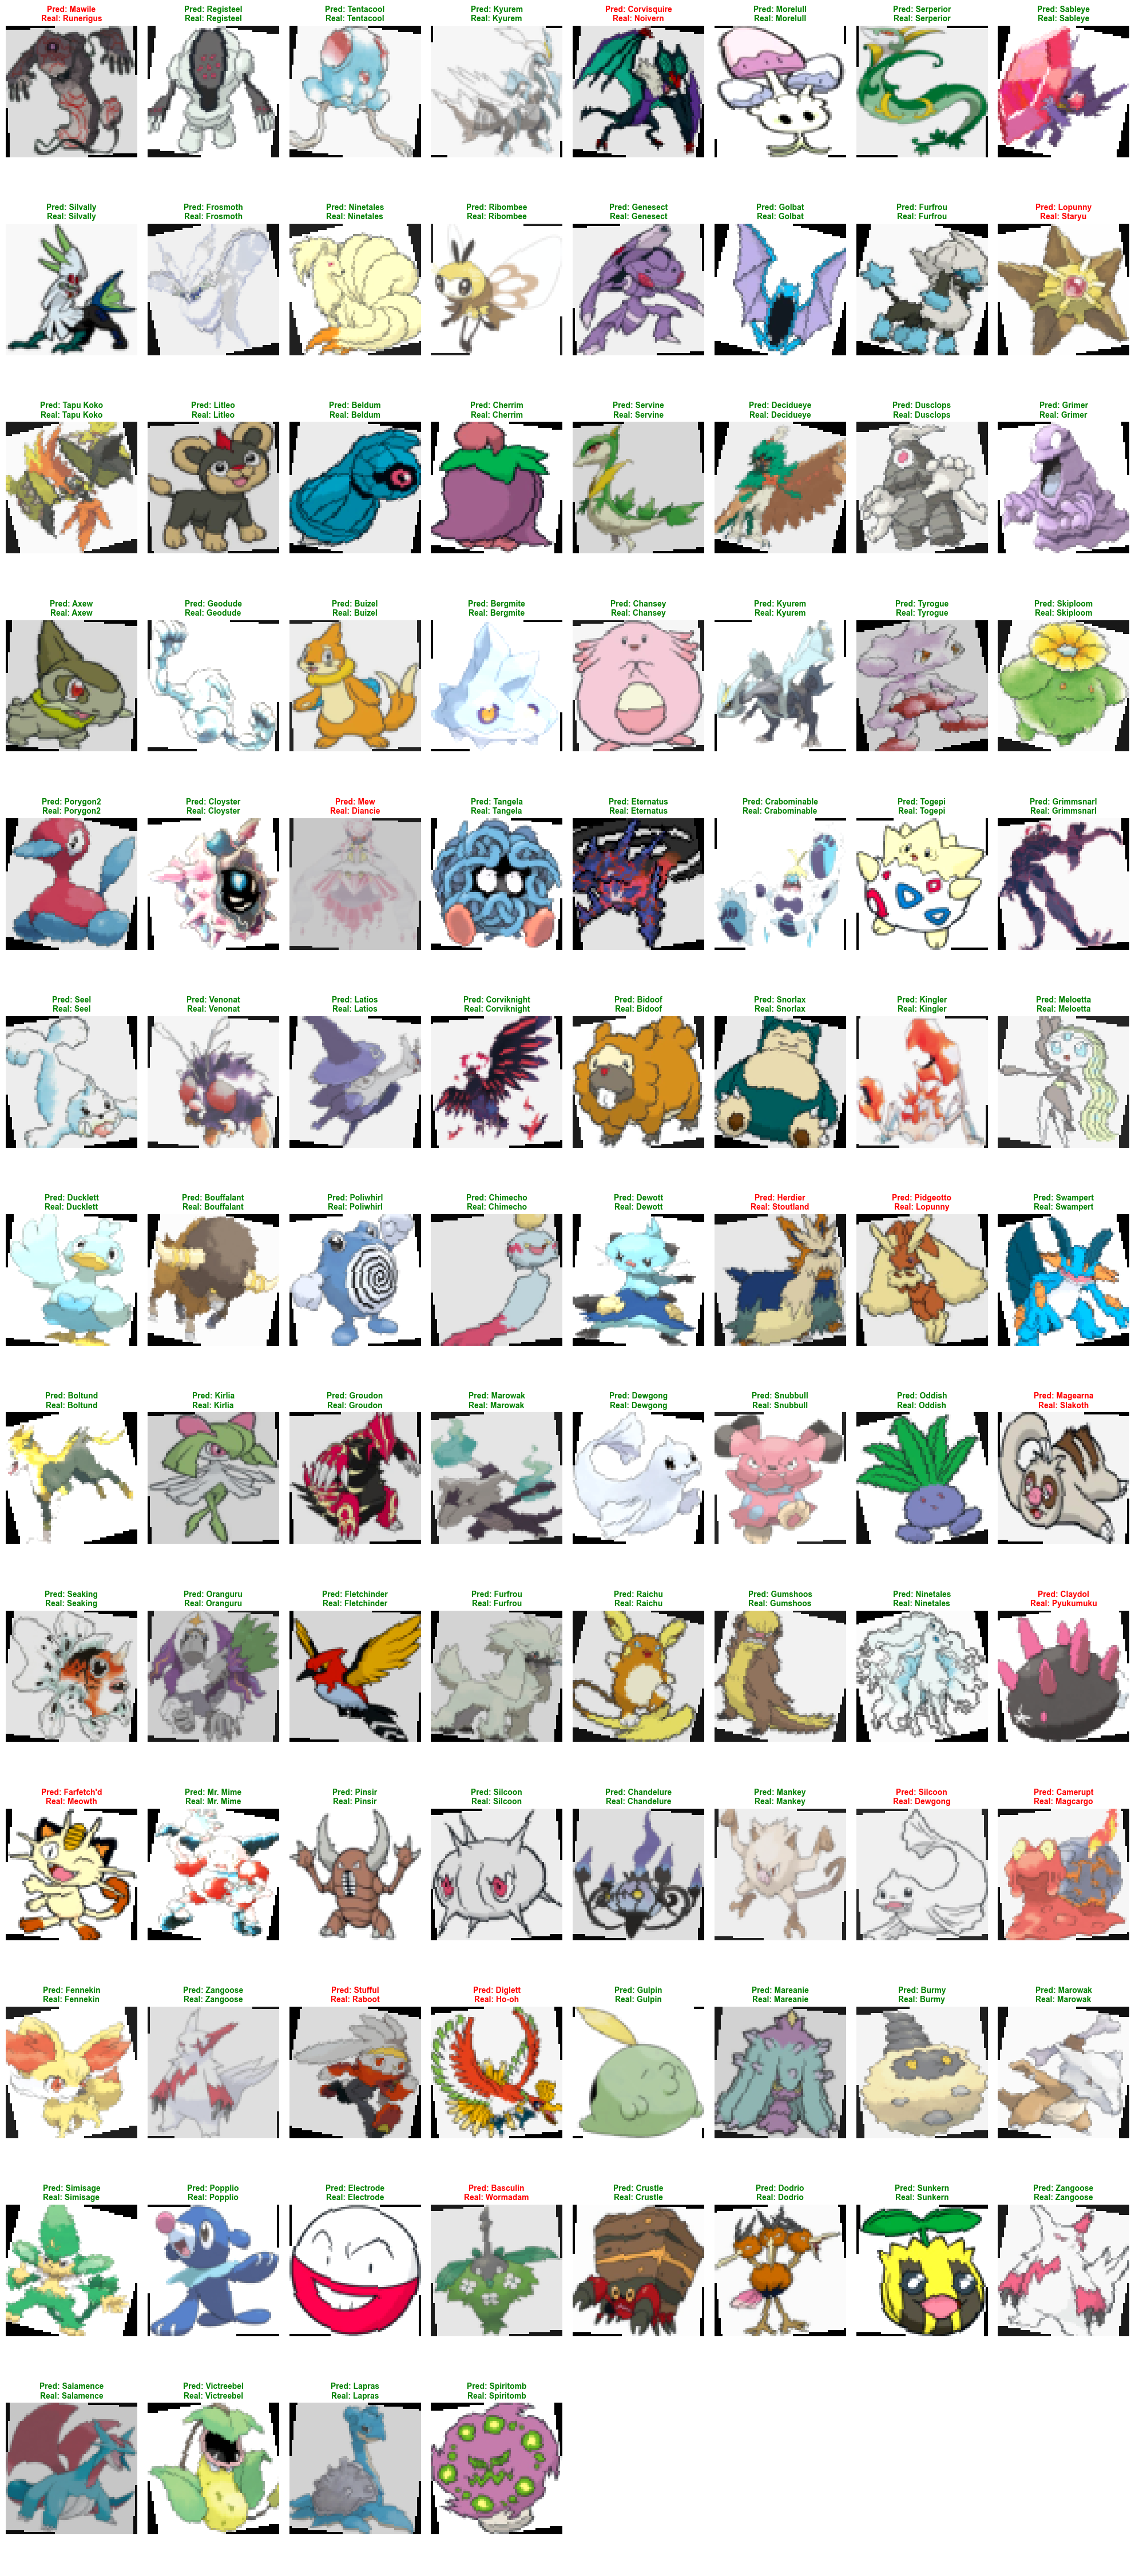

In [21]:
q_model_path = "../results/quantized_models/cnn_mnist_quantized2026-01-06_19-28-23.pt"
f_model_path = "../results/models/cnn_mnist_2026-01-06_19-08-22.pt"

f_model, q_model = load_models(float_path=f_model_path, quant_path=q_model_path)
train_loader, test_loader, *_ = get_data_loaders()

visualize_comparison(model_f=f_model, model_q=q_model, test_loader=test_loader, num_images=100)

In [22]:
weights_floats = f_model.conv1.weight.data.clone().cpu()

# Quantisiert (Simuliert: Float -> Int8 -> Float)
# Wir nutzen deine existierende Funktion, um zu sehen, was aus den Floats wird
weights_dequant, _, _, _ = Quantization.quantize_tensor(weights_floats, num_bits=8, method='affine')

# Flatten für Plots
flat_float = weights_floats.view(-1).numpy()
flat_dequant = weights_dequant.view(-1).numpy()

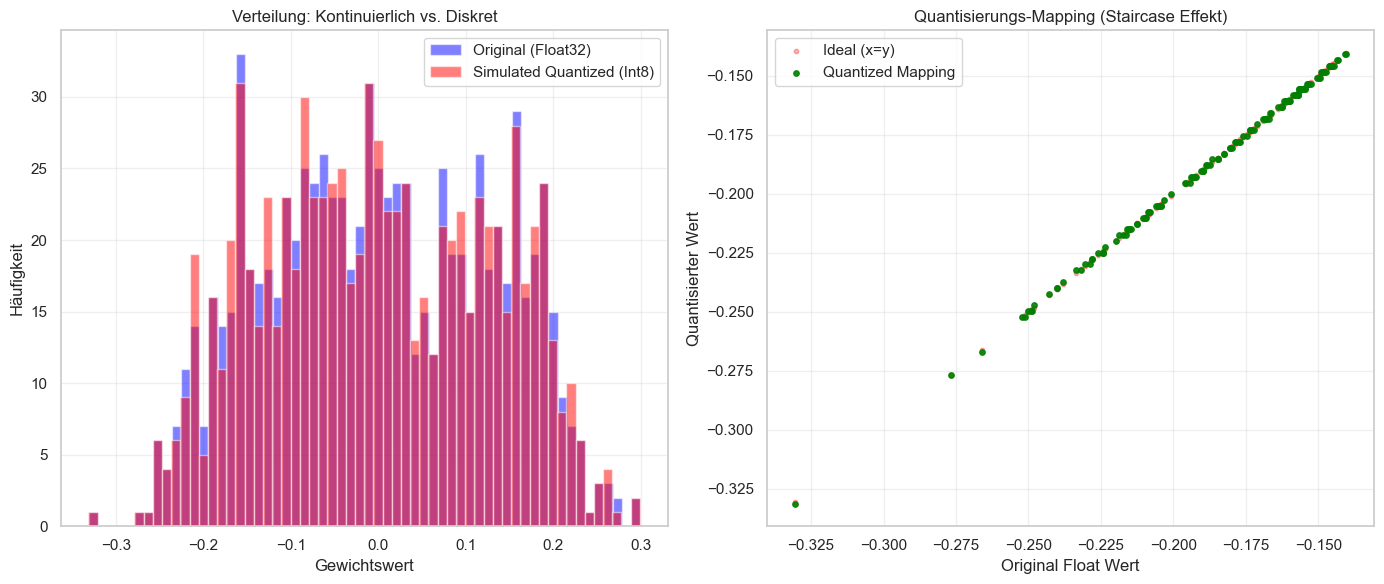

In [23]:
# -------------------------------------------------------
# PLOT 1: Histogramm Überlagerung
# -------------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
# Original
plt.hist(flat_float, bins=60, color='blue', alpha=0.5, label="Original (Float32)")
# Quantized (Zeigt die "Bins")
plt.hist(flat_dequant, bins=60, color='red', alpha=0.5, label="Simulated Quantized (Int8)")

plt.title("Verteilung: Kontinuierlich vs. Diskret")
plt.xlabel("Gewichtswert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True, alpha=0.3)

# -------------------------------------------------------
# PLOT 2: Die Treppenfunktion (Visualisierung des Fehlers)
# -------------------------------------------------------
plt.subplot(1,2,2)

# Wir nehmen nur eine Teilmenge (z.B. 100 Werte), damit man die Punkte sieht
subset_idx = np.argsort(flat_float)[:150] # Sortieren für schönere Linie

plt.scatter(flat_float[subset_idx], flat_float[subset_idx], 
            color='red', alpha=0.3, label="Ideal (x=y)", s=10)
            
plt.scatter(flat_float[subset_idx], flat_dequant[subset_idx], 
            color='green', alpha=0.9, label="Quantized Mapping", s=15)

plt.title("Quantisierungs-Mapping (Staircase Effekt)")
plt.xlabel("Original Float Wert")
plt.ylabel("Quantisierter Wert")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()